In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py

In [6]:
meta = pd.read_csv(
    "chunk2.csv",
    low_memory=False
)

print(meta.head())

  network_code receiver_code receiver_type  receiver_latitude  \
0           TA          109C            BH            32.8889   
1           TA          109C            BH            32.8889   
2           TA          109C            BH            32.8889   
3           TA          109C            BH            32.8889   
4           TA          109C            BH            32.8889   

   receiver_longitude  receiver_elevation_m  p_arrival_sample p_status  \
0           -117.1051                 150.0             700.0   manual   
1           -117.1051                 150.0             600.0   manual   
2           -117.1051                 150.0             500.0   manual   
3           -117.1051                 150.0             900.0   manual   
4           -117.1051                 150.0             700.0   manual   

   p_weight  p_travel_sec  ...  source_magnitude_author  \
0       0.5     17.080000  ...                      NaN   
1       0.5     16.879999  ...                

In [7]:
print(meta.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 35 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   network_code                      200000 non-null  object 
 1   receiver_code                     200000 non-null  object 
 2   receiver_type                     200000 non-null  object 
 3   receiver_latitude                 200000 non-null  float64
 4   receiver_longitude                200000 non-null  float64
 5   receiver_elevation_m              200000 non-null  float64
 6   p_arrival_sample                  200000 non-null  float64
 7   p_status                          200000 non-null  object 
 8   p_weight                          199937 non-null  float64
 9   p_travel_sec                      200000 non-null  float64
 10  s_arrival_sample                  200000 non-null  float64
 11  s_status                          200000 non-null  o

In [39]:
meta = meta[meta["trace_category"] == "earthquake_local"]

meta = meta.dropna(subset=["p_arrival_sample"])

meta["p_arrival_sample"] = meta["p_arrival_sample"].astype(int)

In [40]:
from sklearn.model_selection import train_test_split

unique_events = meta["source_id"].unique()

train_events, test_events = train_test_split(
    unique_events,
    test_size=0.2,
    random_state=42
)

train_meta = meta[meta["source_id"].isin(train_events)]
test_meta  = meta[meta["source_id"].isin(test_events)]

In [41]:
def create_dataset(df):
    X, y = [], []

    with h5py.File("chunk2.hdf5", "r") as f:

        for _, row in df.iterrows():

            try:
                trace = row["trace_name"]
                p = int(row["p_arrival_sample"])

                if p < 1200:
                    continue

                data = f["data"][trace][:]
                z = data[:,2]

                noise = z[p-1600:p-800]
                p_wave = z[p-400:p+400]

                for signal, label in [(noise,0),(p_wave,1)]:

                    if len(signal) != 800:
                        continue

                    signal = (signal - np.mean(signal)) / np.std(signal)

                    X.append(signal)
                    y.append(label)

            except:
                continue

    return np.array(X), np.array(y)

In [42]:
X_train, y_train = create_dataset(train_meta)
X_test, y_test = create_dataset(test_meta)

X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(X_train.shape, X_test.shape)

(432, 800, 1) (113, 800, 1)


In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

model = Sequential([
    Conv1D(32, 7, activation='relu', input_shape=(800,1)),
    MaxPooling1D(2),

    Conv1D(64, 5, activation='relu'),
    MaxPooling1D(2),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

c:\Users\HOME\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [54]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 1.0000 - loss: 1.5509e-05 - val_accuracy: 0.9823 - val_loss: 0.0911
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 1.0000 - loss: 1.3618e-05 - val_accuracy: 0.9823 - val_loss: 0.0970
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 1.0000 - loss: 1.1809e-05 - val_accuracy: 0.9823 - val_loss: 0.0999
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 1.0000 - loss: 1.1299e-05 - val_accuracy: 0.9823 - val_loss: 0.0975
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 1.0000 - loss: 9.1501e-06 - val_accuracy: 0.9823 - val_loss: 0.1024
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 1.0000 - loss: 8.3525e-06 - val_accuracy: 0.9823 - val_loss: 0.1038
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 1.0000 - loss: 7.5968e-06 - val_accuracy: 0.9823 - val_loss: 0.1047
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 1.0000 - loss: 7.111

In [55]:
loss, acc = model.evaluate(X_test, y_test, verbose=1)

print("Test Loss:", loss)
print("Test Accuracy:", acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9823 - loss: 0.1083
Test Loss: 0.10828346014022827
Test Accuracy: 0.982300877571106


In [56]:
y_pred = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [57]:
y_pred_classes = (y_pred > 0.5).astype(int).reshape(-1)

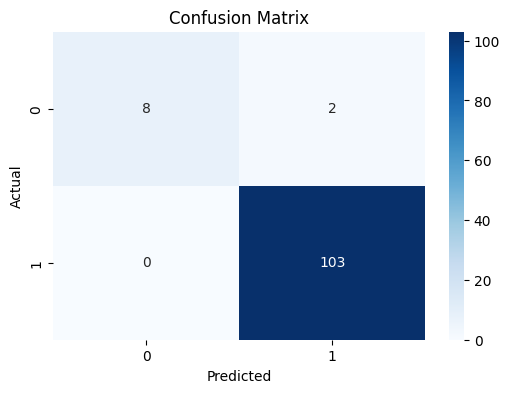

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [59]:
print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       1.00      0.80      0.89        10
           1       0.98      1.00      0.99       103

    accuracy                           0.98       113
   macro avg       0.99      0.90      0.94       113
weighted avg       0.98      0.98      0.98       113

